# Comprensión de los datos

Se va a mostrar cómo se haría la fase de comprensión de los datos usando **Pandas**. Para esto se va a trabajar con un dataset que contiene datos de clientes de una empresa de telecomunicaciones.

La formulación del problema que se desea resolver con el análisis de datos es la siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga y descripción de los datos

Se empieza con la carga del conjunto de datos, teniendo en cuenta que tiene datos nulos que no reconoce Pandas automáticamente:

In [1]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "raw"
data_file = "Telco_customer_churn.csv"
data_path = DATA_DIR / data_file

In [2]:
import pandas as pd

df = pd.read_csv(
    data_path,
    #na_values=[' ']
    )

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Las primeras preguntas que deberían responderse son las siguientes:

- ¿Cuántas filas y columnas tiene el conjunto de datos?
- ¿Qué tipos de variables contiene (numéricas, categóricas, texto, fechas, booleanas)?
- ¿Las variables están en el tipo de dato correcto para su contenido?

Estas preguntas se pueden empezar a responder con la información que entrega el método `info`:


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Se observa que la variable **Total Charges** quedó con el tipode dato incorrecto, porque tienen datos nulos que no fueron identificados por Pandas. Esto se puede solucionar así:

In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Descripción de los datos e identificación de problemas

En esta parte respondemos preguntas como:

- ¿Hay valores fuera de rango o imposibles según el dominio del problema?
- ¿Hay variables que no varían?
- ¿Cuáles variables categóricas tienen muchos valores únicos (alta cardinalidad)?
- ¿Cuáles son claves primarias o identificadores únicos?
- ¿Hay formatos no estandarizados (fechas, monedas, mayúsculas/minúsculas)?

Este tipo de preguntas se puede empezar a responder con el método `describe`, que nos entrega las principales estadísticas descriptivas de las variables:

In [10]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [6]:
df['Churn Value'].unique() # Aquí me muestra los valores que toma la variable

array([1, 0])

En este caso:
- No pareciera que haya valores imposibles para las variables numéricas.
- Se observa que la variable **Count** toma un solo valor (porque std = 0), mientras que **Churn Value** es en realidad una variable cualitativa, porque solo toma 2 valores(Lo podemos ver en min, max y los cuartiles).

Con `describe` también se pueden analizar variables cualitativas (porque por defecto solo las saca para las variables numéricas):

In [11]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


Aquí se observa que la variable **CustomerID** es una clave primaria o identificador único, porque toma tantos valores diferentes como registros hay.

También se observa que las variables **Country** y **State** son constantes, es decir solo toman un valor para todos los registros.

Por último, se observa que las variables **City** y **Lat Long** tienen muy alta cardinalidad.

Para saber si hay categorías *extrañas* o *inesperadas*, posiblemente por errores de codificación, ortografía o formatos no homogéneos, se puede usar el método `unique`, que muestra todos los valores que toma una variable:


In [12]:
cat_cols = df.drop(['CustomerID', 'Country', 'State', 'City'], axis=1).select_dtypes(include=['object']).columns

for col in cat_cols:
    print('Etiquetas de la variable ', col, ':\n')
    print(df[col].unique())
    print('\n')

Etiquetas de la variable  Lat Long :

['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']


Etiquetas de la variable  Gender :

['Male' 'Female']


Etiquetas de la variable  Senior Citizen :

['No' 'Yes']


Etiquetas de la variable  Partner :

['No' 'Yes']


Etiquetas de la variable  Dependents :

['No' 'Yes']


Etiquetas de la variable  Phone Service :

['Yes' 'No']


Etiquetas de la variable  Multiple Lines :

['No' 'Yes' 'No phone service']


Etiquetas de la variable  Internet Service :

['DSL' 'Fiber optic' 'No']


Etiquetas de la variable  Online Security :

['Yes' 'No' 'No internet service']


Etiquetas de la variable  Online Backup :

['Yes' 'No' 'No internet service']


Etiquetas de la variable  Device Protection :

['No' 'Yes' 'No internet service']


Etiquetas de la variable  Tech Support :

['No' 'Yes' 'No internet service']


Etiquetas de la variable  Streaming TV :

['N

Abajo se muestran las categorías de la variable **City**:

In [9]:
cities = df['City'].unique().tolist()
for city in cities:
  print(city)

Los Angeles
Beverly Hills
Huntington Park
Lynwood
Marina Del Rey
Inglewood
Santa Monica
Torrance
Whittier
La Habra
Pico Rivera
Avalon
Harbor City
Lakewood
Los Alamitos
San Pedro
Carson
Long Beach
Altadena
Monrovia
Sierra Madre
Tujunga
Pasadena
Glendale
Canoga Park
Mission Hills
Santa Clarita
Sun Valley
Stevenson Ranch
Panorama City
Van Nuys
Burbank
North Hollywood
Covina
El Monte
La Puente
Rowland Heights
Ontario
Pomona
Rosemead
San Dimas
West Covina
Alhambra
Alpine
Bonita
Boulevard
Guatay
Jacumba
Mount Laguna
Borrego Springs
Carlsbad
Del Mar
El Cajon
Escondido
Oceanside
Pala
Palomar Mountain
Pauma Valley
Ranchita
Valley Center
San Diego
Indio
Indian Wells
Palm Desert
Desert Hot Springs
Holtville
Niland
North Palm Springs
Ocotillo
Seeley
Thermal
Adelanto
Apple Valley
Crestline
Daggett
Ludlow
Lucerne Valley
Lytle Creek
Phelan
Redlands
Rialto
Running Springs
Tecopa
Victorville
Wrightwood
San Bernardino
Riverside
March Air Reserve Base
Hemet
Homeland
Idyllwild
Moreno Valley
Murrieta
Perri

Este método funciona bien con variables de baja cardinalidad, pero para variables de alta cardinalidad, habría que usar métodos más avanzados para detectar errores de codificación, tipeo u ortográficos, usando otras librerías especializadas como [FuzzyWuzzy](https://pypi.org/project/fuzzywuzzy/) o [RapidFuzz](https://pypi.org/project/RapidFuzz/).

Un par de preguntas más que habría que responder son: ¿Qué columnas tienen valores nulos? ¿En qué proporción?

El método `info`da alguna información de esto; sin embargo, existen otros métodos especializados como `isnull` o `isna`.

In [13]:
df.isnull().sum().sort_values(ascending=False).head()

Churn Reason     5174
Total Charges      11
CustomerID          0
Count               0
Country             0
dtype: int64

Se encuentra que las variables **Total Charges** y **Churn Reason** tienen datos nulos.

Se puede calcular la proporción de datos nulos que tienen estas variables así:

In [14]:
nulos = df.isnull().sum()/df.shape[0]*100
nulos.sort_values(ascending=False).head()

Churn Reason     73.463013
Total Charges     0.156183
CustomerID        0.000000
Count             0.000000
Country           0.000000
dtype: float64

En este dataset, el 0.16% de los registros tienen datos desconocidos de la variable **Total Charges**, y el 73.46% de los registros tienen datos desconocidos de la variable **Churn Reason**.

Una pregunta más que habría que responder es: ¿Hay registros duplicados?

Esto se podría saber usando el método `duplicated`:

In [15]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


En este caso no hay registros duplicados.

También podría buscarse si hay duplicados por una columna o combinación de columnas:

In [16]:
df.duplicated(subset=['CustomerID']).sum()

np.int64(0)

In [18]:
df.duplicated(subset=['Lat Long']).sum()

np.int64(5391)

En este dataset no hay registros con identificador único repetido.

## Exploración preliminar

En la exploración inicial de los datos se quiere averiguar cómo se comportan estadísticamente los datos.

Se deben responder preguntas tales como:
- ¿Cómo se distribuyen las variables numéricas? (simétrica, sesgada, bimodal...)
- ¿Qué variables presentan valores extremos o atípicos (outliers)?
- ¿Cómo se distribuyen las variables categóricas?
- ¿Existen categorías atípicas?

Para responder la primera pregunta es necesario hacer [histogramas](https://en.wikipedia.org/wiki/Histogram) o gráficos de [densidad](https://en.wikipedia.org/wiki/Kernel_density_estimation).

Los histogramas se pueden generar con el método `hist`:

array([[<Axes: title={'center': 'Zip Code'}>,
        <Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>],
       [<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'Total Charges'}>],
       [<Axes: title={'center': 'Churn Value'}>,
        <Axes: title={'center': 'Churn Score'}>,
        <Axes: title={'center': 'CLTV'}>]], dtype=object)

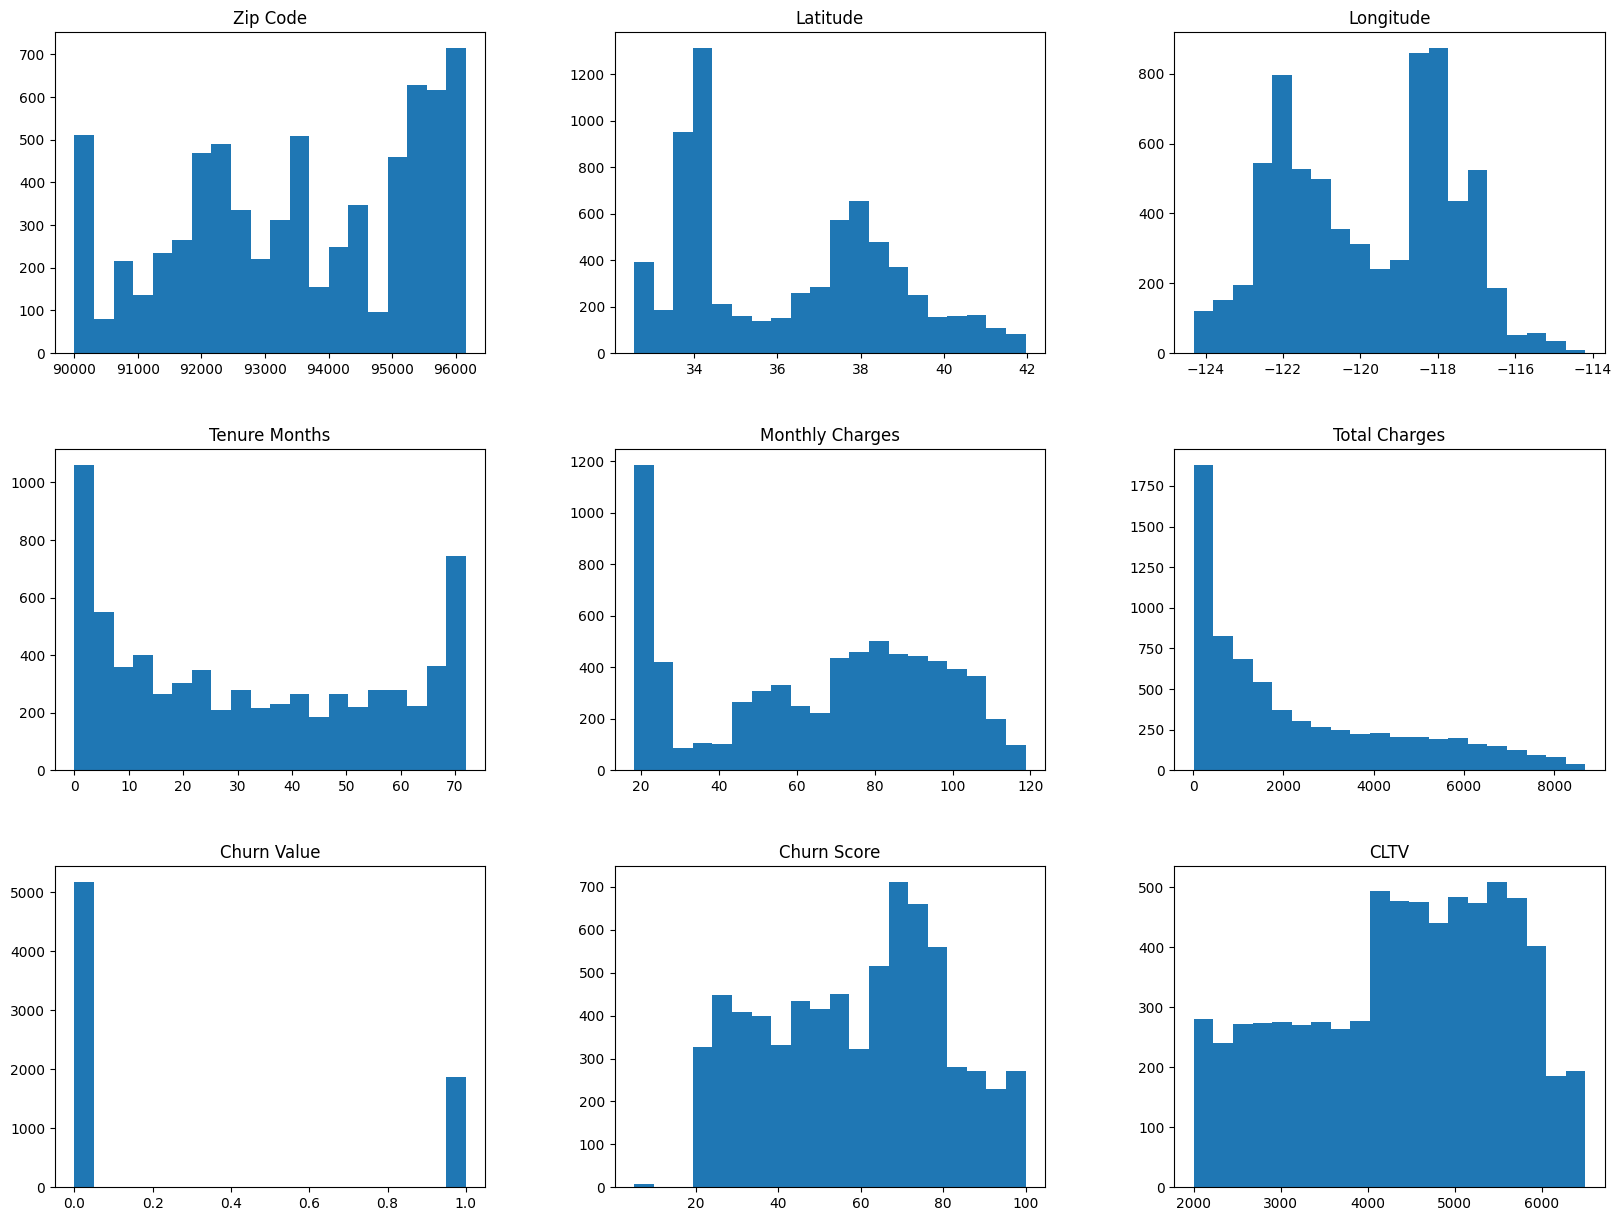

In [17]:
df.drop(['Count'], axis=1).hist(
    figsize=(20, 15),
    bins=20,
    grid=False
    )

Y los gráficos de densidad con `plot(kind='kde')`:

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

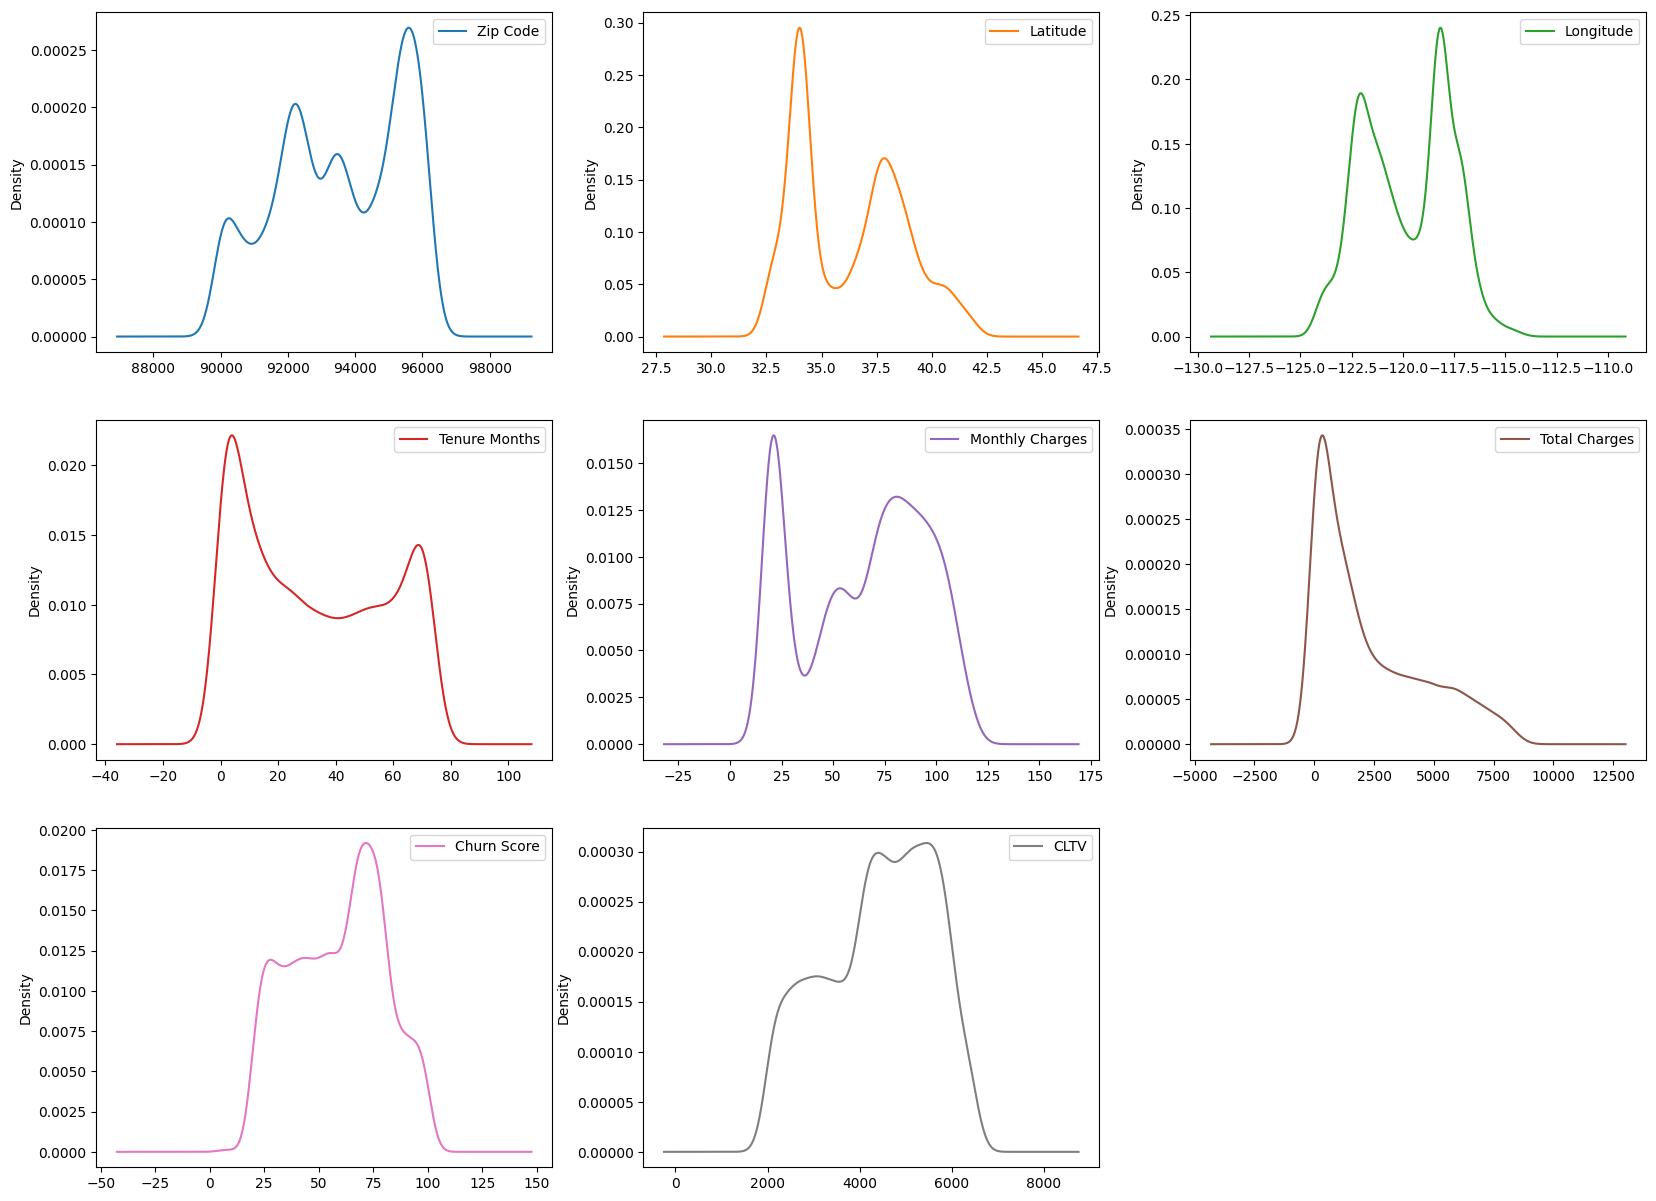

In [19]:
df.drop(['Count', 'Churn Value'], axis=1).select_dtypes(include=['int64', 'float64']).plot(
    kind='kde',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

En este caso, no hay duda de que las variables **no cumplen** con el supuesto de normalidad. En caso de dudas se puede medir la **curtosis** y **asimetría** de la variable, usando los métodos `kurt`y `skew` respectivamente, o hacer **pruebas de bondad de ajuste**, usando la librería `Scipy`.


In [20]:
df['Latitude'].kurt()

np.float64(-1.1356071421034115)

In [21]:
df['Latitude'].skew()

np.float64(0.30386729287920206)

**Nota:** Obsérvese que en este caso las medidas no están tan alejadas de 0, a pesar de que la variable claramente no es normal. **Las medidas por sí solas no son un criterio válido**.

La mejor manera de saber si hay datos atípicos es usando gráficos de cajas y bigotes, o [box plots](https://en.wikipedia.org/wiki/Box_plot).

En **Pandas**, los **boxplots** se pueden hacer usando el método `plot(kind='box')`:

Zip Code              Axes(0.125,0.653529;0.227941x0.226471)
Latitude           Axes(0.398529,0.653529;0.227941x0.226471)
Longitude          Axes(0.672059,0.653529;0.227941x0.226471)
Tenure Months         Axes(0.125,0.381765;0.227941x0.226471)
Monthly Charges    Axes(0.398529,0.381765;0.227941x0.226471)
Total Charges      Axes(0.672059,0.381765;0.227941x0.226471)
Churn Score               Axes(0.125,0.11;0.227941x0.226471)
CLTV                   Axes(0.398529,0.11;0.227941x0.226471)
dtype: object

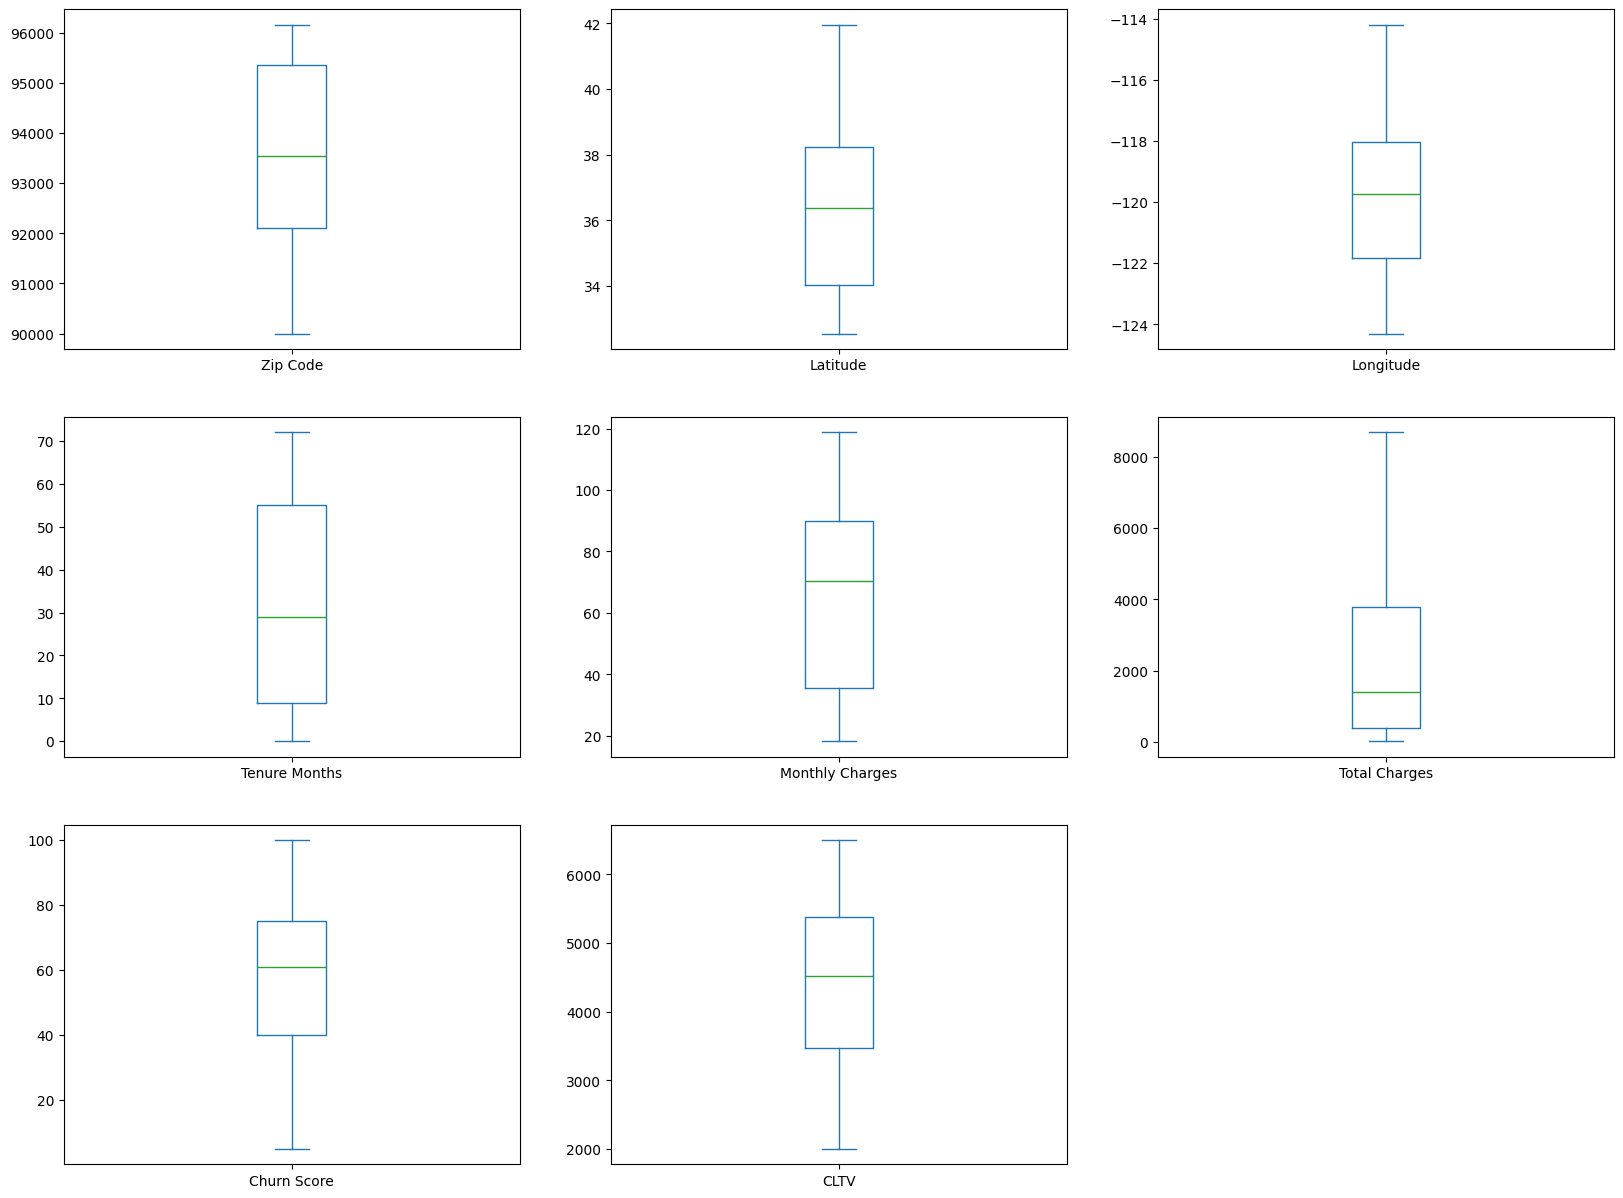

In [22]:
df.drop(['Count', 'Churn Value'], axis=1).select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

Si se observaran puntos por fuera de los bigotes serían valores atípicos. En este caso ninguna variable cuantitativa tiene valores atípicos.

La distribución de las variables categóricas se puede observar mediante gráficos de barras, que en `Pandas` se generan usando el método `plot(kind='bar')`.

En estas gráficas también se podría ver sí hay categorías atípicas.


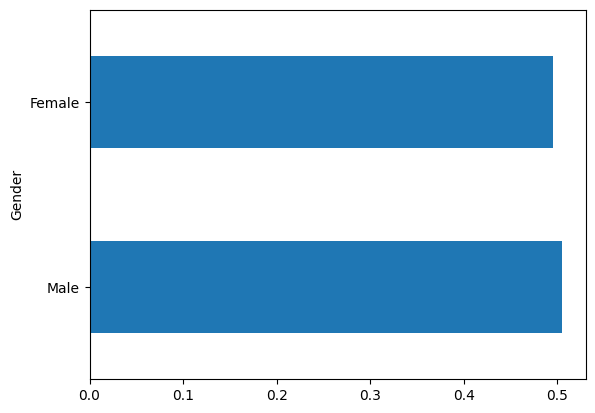

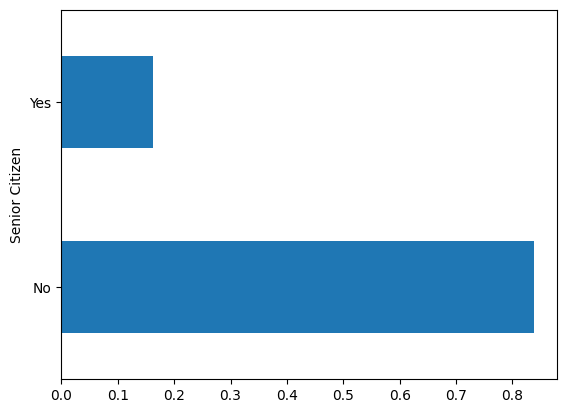

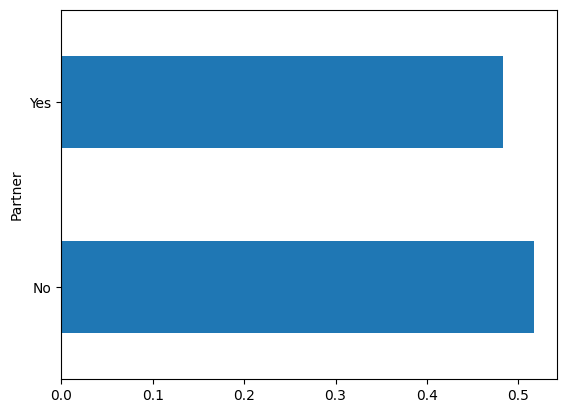

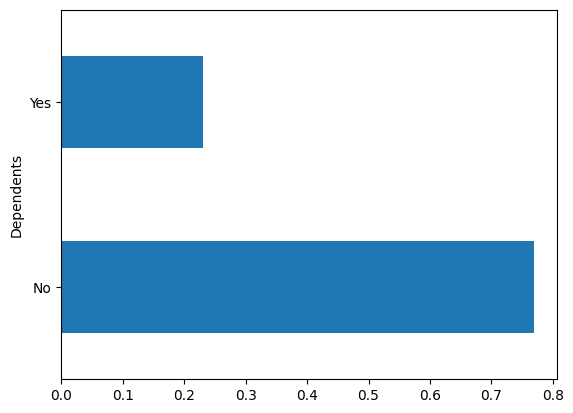

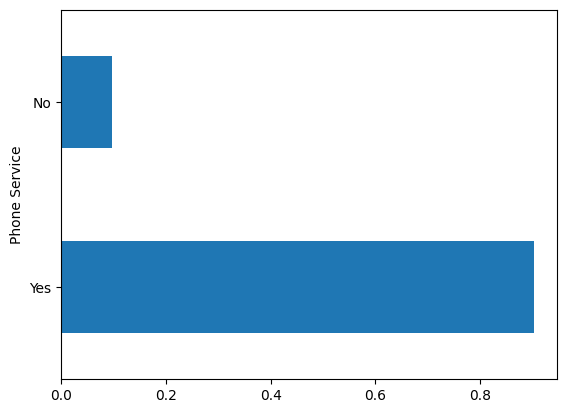

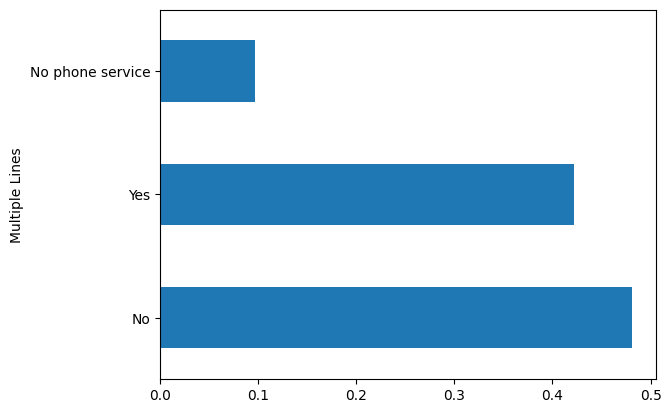

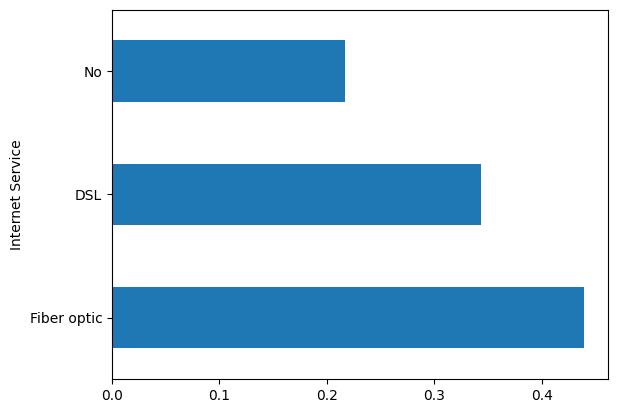

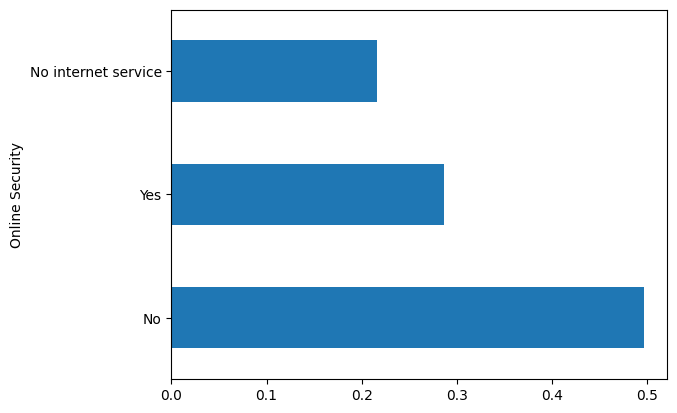

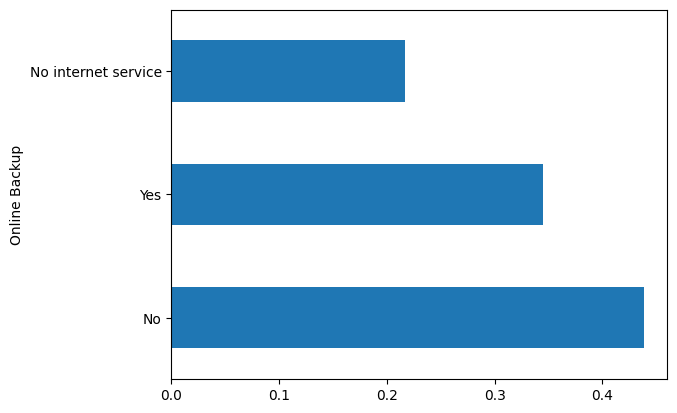

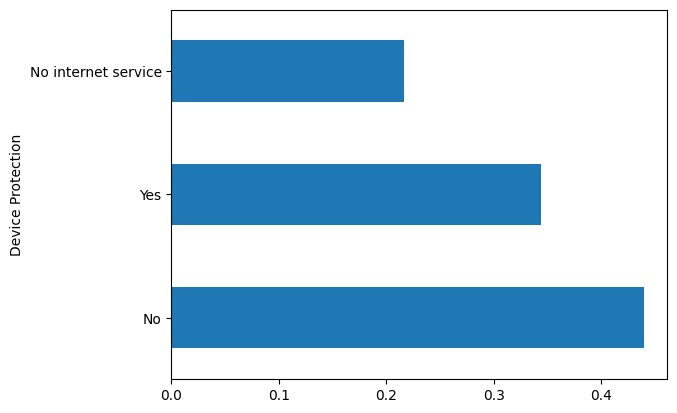

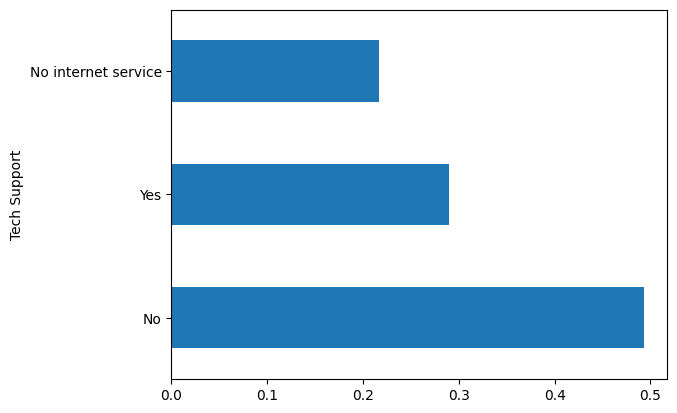

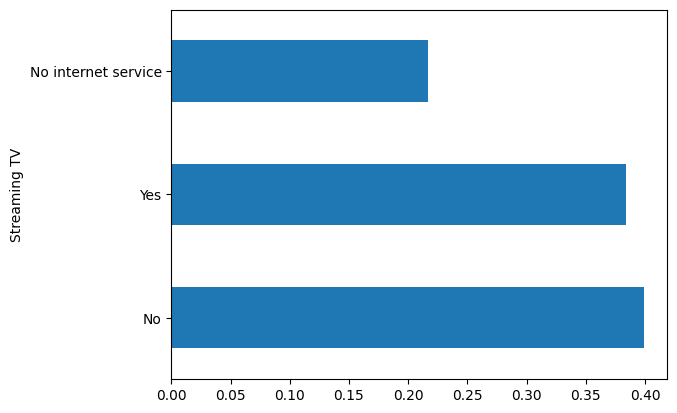

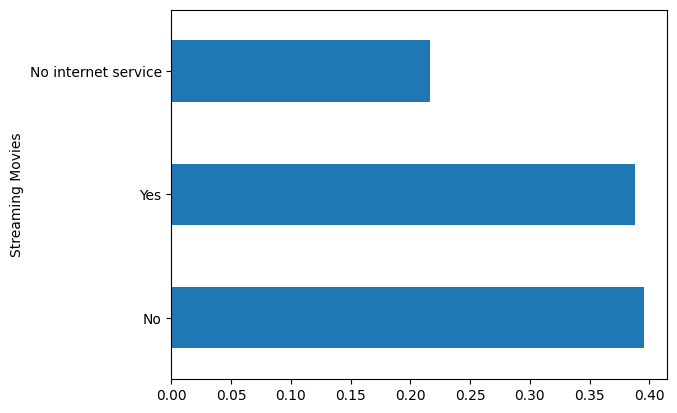

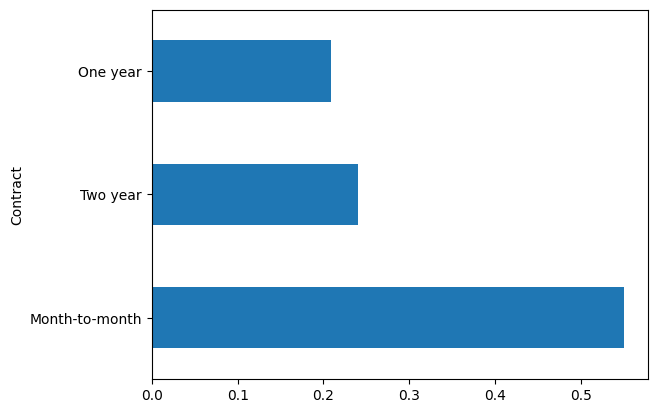

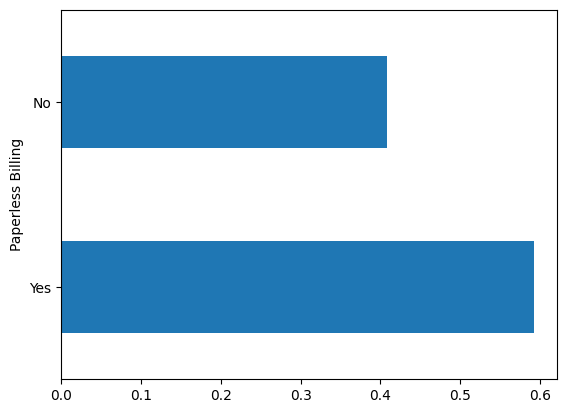

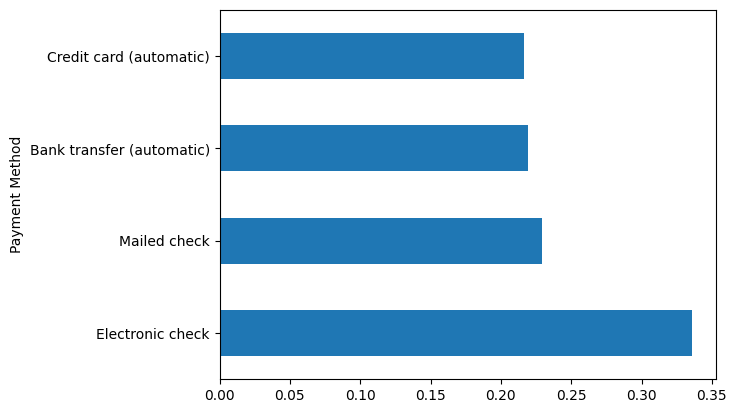

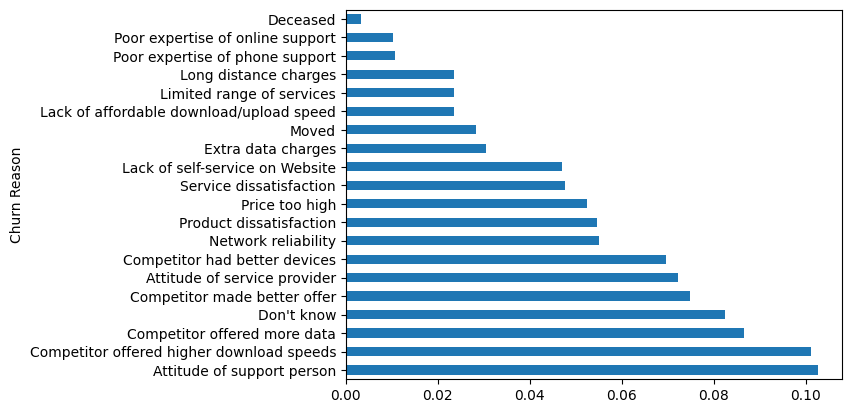

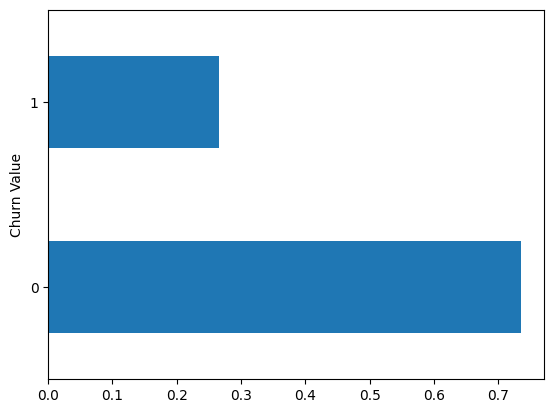

In [24]:
import matplotlib.pyplot as plt

# Se seleccionan las variables tipo objeto del dataframe y se añaden las variables Count y Churn Value porque también son cualitativas
cat_vars = list(df.select_dtypes(include=['object']).columns) + ['Churn Value']
# Se eliminan variables con muy alta cardinalidad, o con valores únicos
cat_vars = [var for var in cat_vars if var not in ['City', 'Churn Label', 'CustomerID', 'Lat Long','State', 'Country']]

for var in cat_vars:
    plt.figure()
    df[var].value_counts(normalize=True).plot(kind='barh')
    plt.show();

Otra forma de saber sí hay categorías atípicas es usando el método `value_counts`:

In [25]:
for var in cat_vars:
    print(f'Categorías de la variable {var}:')
    print(df[var].value_counts())
    print('\n')

Categorías de la variable Gender:
Gender
Male      3555
Female    3488
Name: count, dtype: int64


Categorías de la variable Senior Citizen:
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64


Categorías de la variable Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64


Categorías de la variable Dependents:
Dependents
No     5416
Yes    1627
Name: count, dtype: int64


Categorías de la variable Phone Service:
Phone Service
Yes    6361
No      682
Name: count, dtype: int64


Categorías de la variable Multiple Lines:
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


Categorías de la variable Internet Service:
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Categorías de la variable Online Security:
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


Categoría

En este caso podría decirse que la categoría *Deceased* de de la variable **Churn Reason** es una categoría atípica, ya que su frecuencia relativa es menos del $1\%$ del total de muestras.

# Ejercicio

Haga este mismo análisis para el archivo **adult_modified.data**.